In [228]:
import tensorflow_datasets as tfds
import cv2
import numpy as np
from tensorflow.keras.models import load_model
from ultralytics import YOLO
import matplotlib.pylab as plt
from keras.models import Sequential
from  keras.layers import Dense , Conv2D , Flatten , MaxPooling2D
import random


In [35]:
ds_train , ds_test = tfds.load('emnist/balanced' , split= ["train" , "test"] , as_supervised=True , batch_size = -1)

In [36]:
x_train , y_train = tfds.as_numpy(ds_train)
x_test , y_test = tfds.as_numpy(ds_test)

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(112800, 28, 28, 1)
(112800,)
(18800, 28, 28, 1)
(18800,)


't'

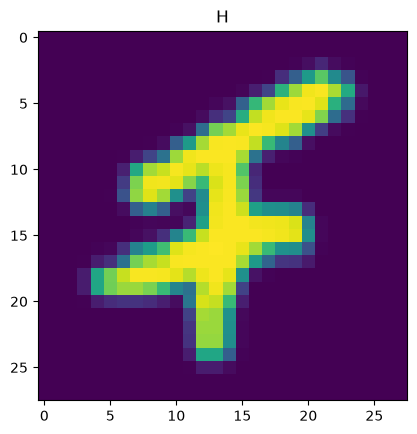

In [249]:
def fix_emnist_image(img):
    img = np.reshape(img ,( 28 , 28))
    img = np.fliplr(img)
    img = np.rot90(img)
    return img


# mapping دقیق برای balanced 
EMNIST_BALANCED_CHARS = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt'

def balanced_label_to_char(label):
    return EMNIST_BALANCED_CHARS[label]

ind = 164
im = fix_emnist_image(x_train[ind])
plt.imshow(im)
plt.title(label=balanced_label_to_char(y_train[ind]))

EMNIST_BALANCED_CHARS[-1]

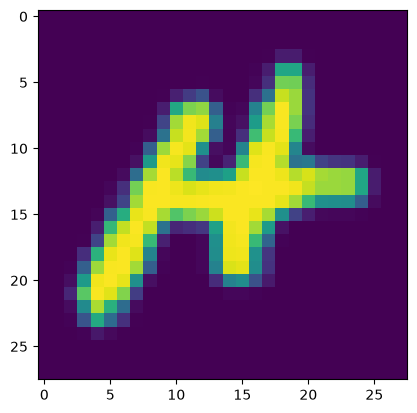

In [38]:
# plt.imshow(fix_emnist_image(x_train[4]))
lst = []
for img in x_train:
    img = fix_emnist_image(img)
    lst.append(img)
    
x_train = lst
x_train = np.array(x_train)




lst2 = []
for img_t in x_test:
    img_t = fix_emnist_image(img_t)
    lst2.append(img_t)
    
x_test = lst2
x_test = np.array(x_test)



plt.imshow(x_test[4])
plt.imshow(x_train[164])

In [39]:
x_train = x_train / 255
x_test = x_test / 255


print(f"x_train = min:{x_train[0].min()} , max:{x_train[0].max()}")
print(f"x_test = min:{x_test[0].min()} , max:{x_test[0].max()}")

x_train = min:0.0 , max:1.0
x_test = min:0.0 , max:1.0


In [40]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation="relu"))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation="relu"))
model.add(Dense(47, activation="softmax"))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(optimizer="adam" , loss="sparse_categorical_crossentropy" , metrics=["accuracy"])

In [42]:
# model.fit(x_train , y_train , validation_data=(x_test , y_test) , epochs=7 , batch_size=64)
# model.save("EMNIST.weight.h5")
model = load_model("EMNIST.weight.h5")

loss , acc = model.evaluate(x_test , y_test)
print(f"acc: {acc}")

588/588 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8713 - loss: 0.3799
acc: 0.8713297843933105


yolo and plate preprocessing


In [ ]:
# Run on Colab due to the presence of a GPU.

# import os
# import kagglehub
# from sklearn.model_selection import train_test_split
# import random
# import xml.etree.ElementTree as ET
# import shutil
# from ultralytics import YOLO


# #----------------------------------------------

# path = kagglehub.dataset_download("andrewmvd/car-plate-detection")

# #------------------------------------------------

# annotations_path = os.path.join(path, "annotations")
# images_path = os.path.join(path, "images")

# #--------------------------------------------------

# xml_files = [f for f in os.listdir(annotations_path) if f.endswith('.xml')]
# print(f"annotation len: {len(xml_files)}")

# #-----------------------------------------------

# random.seed(42)
# random.shuffle(xml_files)

# split_idx = int(len(xml_files) * 0.85)
# train_files = xml_files[:split_idx]
# val_files = xml_files[split_idx:]

# or:

# train_files, val_files = train_test_split(
#     xml_files,
#     test_size=0.15,     
#     random_state=42      
# )

# print(f"train: {len(train_files)}, val: {len(val_files)}")

# #-------------------------------------------------

# output_path = "/content/dataset"  # مسیر دلخواه

# for split in ["train", "val"]:
#     os.makedirs(f"{output_path}/images/{split}", exist_ok=True)
#     os.makedirs(f"{output_path}/labels/{split}", exist_ok=True)
    
    
# #-------------------------------------------------


# def convert_voc_to_yolo(xml_path):
#     tree = ET.parse(xml_path)
#     root = tree.getroot()
    
#     img_width = int(root.find('size/width').text)
#     img_height = int(root.find('size/height').text)
    
#     yolo_lines = []
#     for obj in root.findall('object'):
#         bbox = obj.find('bndbox')
#         xmin = float(bbox.find('xmin').text)
#         ymin = float(bbox.find('ymin').text)
#         xmax = float(bbox.find('xmax').text)
#         ymax = float(bbox.find('ymax').text)
        
#         x_center = ((xmin + xmax) / 2) / img_width
#         y_center = ((ymin + ymax) / 2) / img_height
#         w = (xmax - xmin) / img_width
#         h = (ymax - ymin) / img_height
        
#         yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
    
#     return yolo_lines


# #-------------------------------------------------



# def process_files(file_list, split_name):
#     for xml_file in file_list:
#         base_name = xml_file.replace('.xml', '')  # مثلاً "Cars80"
        
#         xml_path = os.path.join(annotations_path, xml_file)
#         img_path = os.path.join(images_path, base_name + '.png')
        
#         if not os.path.exists(img_path):
#             print(f"تصویر پیدا نشد: {img_path}")
#             continue
        
#         yolo_lines = convert_voc_to_yolo(xml_path)
        
#         with open(f"{output_path}/labels/{split_name}/{base_name}.txt", "w") as f:
#             f.write("\n".join(yolo_lines))
        
#         shutil.copy(img_path, f"{output_path}/images/{split_name}/{base_name}.png")

# process_files(train_files, "train")
# process_files(val_files, "val")

# print("finish")

# #--------------------------------------------------

# train_imgs = set(f.replace('.png', '') for f in os.listdir(f"{output_path}/images/train"))
# train_lbls = set(f.replace('.txt', '') for f in os.listdir(f"{output_path}/labels/train"))

# print("تناظر کامله:", train_imgs == train_lbls)


# #----------------------------------------------------------


# yaml_content = f"""
# train: {output_path}/images/train
# val: {output_path}/images/val

# nc: 1
# names: ['licence_plate']
# """

# with open(f"{output_path}/data.yaml", "w") as f:
#     f.write(yaml_content)

# print(yaml_content)



# #-------------------------------------------------------------



# model = YOLO("yolov8n.pt")  

# results = model.train(
#     data=f"{output_path}/data.yaml",
#     epochs=30,
#     imgsz=640,
#     batch=16,
#     patience=15,  
#     name="license_plate_detector"
# )


# #-----------------------------------------------


# metrics = model.val()

# print(f"mAP50: {metrics.box.map50}")     
# print(f"mAP50-95: {metrics.box.map}")    
# print(f"Precision: {metrics.box.mp}")
# print(f"Recall: {metrics.box.mr}")


# #-------------------------------------------------

# from google.colab import files
# files.download("runs/detect/license_plate_detector-2/weights/best.pt")



In [44]:
yolo_model = YOLO("best.pt")
results = yolo_model.predict("plate.png" , conf = .5)

for i , box in enumerate(results[0].boxes):
    print(i , box.xyxy[0].tolist())


image 1/1 c:\Users\idjaf\OneDrive\Desktop\deep learning\projet3\plate.png: 640x480 1 licence_plate, 2596.5ms
Speed: 49.4ms preprocess, 2596.5ms inference, 48.5ms postprocess per image at shape (1, 3, 640, 480)
0 [156.93429565429688, 264.0287170410156, 228.56466674804688, 286.20001220703125]


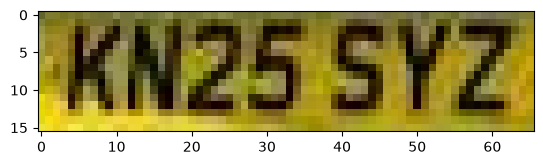

tensor([156.9343, 264.0287, 228.5647, 286.2000])

In [ ]:

b = results[0].boxes.xyxy[0].tolist()

img = cv2.imread("plate.png")
img = cv2.cvtColor(img , cv2.COLOR_RGB2BGR)
x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[2]), int(b[3])
cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 1)

img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
cv2.imshow("car" , img)
cv2.waitKey(0)
cv2.destroyAllWindows()

cropped_plate = img[ y1+3:y2-3 , x1+3:x2-3 ]
cropped_plate = cv2.cvtColor(cropped_plate , cv2.COLOR_BGR2RGB)

plt.imshow(cropped_plate , cmap="gray")
plt.show()



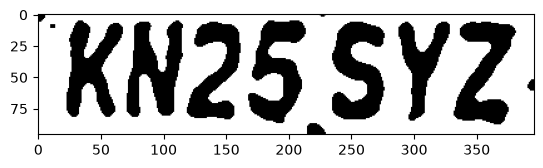

In [ ]:
def normalize(crop_plate):
    scale = 6  
    gray = cv2.cvtColor(crop_plate, cv2.COLOR_BGR2GRAY)

    resized = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    blurred = cv2.GaussianBlur(resized, (7, 7), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)

    _, thresh = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    smoothed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    smoothed = cv2.morphologyEx(smoothed, cv2.MORPH_OPEN, kernel)
    smoothed = cv2.medianBlur(smoothed, 5)
    return smoothed


result = normalize(cropped_plate)
plt.imshow(result, cmap="gray")

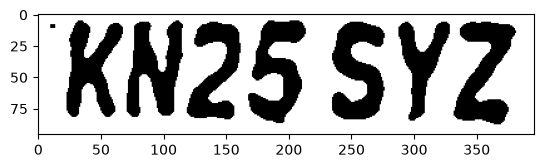

In [ ]:
def delete_noize(plate_crop):

    if len(plate_crop.shape) == 3:
        img = cv2.cvtColor(plate_crop, cv2.COLOR_BGR2GRAY)
    else:
        img = plate_crop

   
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    h, w = binary.shape
    mask = np.zeros((h + 2, w + 2), np.uint8)


    border_points = []
    border_points += [(x, 0) for x in range(w)]
    border_points += [(x, h - 1) for x in range(w)]
    border_points += [(0, y) for y in range(h)]
    border_points += [(w - 1, y) for y in range(h)]

    for x, y in border_points:
        if binary[y, x] == 0: 
            cv2.floodFill(binary, mask, (x, y), 255)
    return binary

d = delete_noize(result)
plt.imshow(d, cmap="gray")
plt.show()


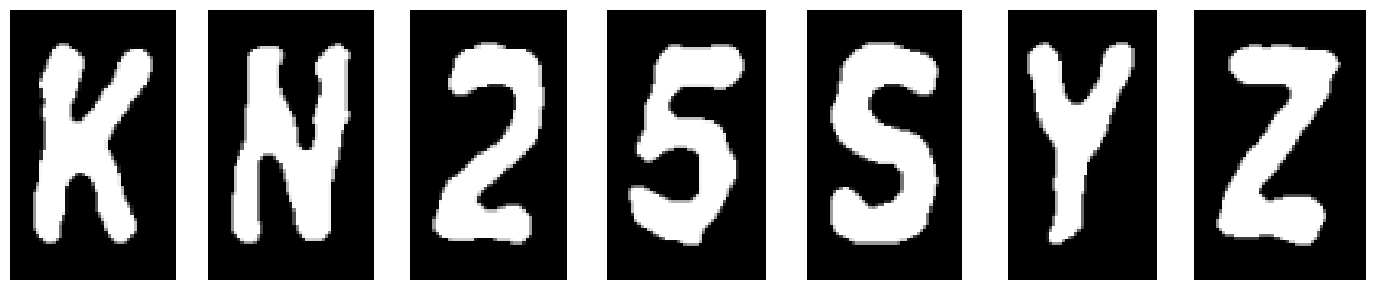

7 کاراکتر پیدا شد


In [ ]:
def segment_plate_characters(img, min_area_ratio=0.01, min_height_ratio=0.35, pad=3, shrink=.7, show=True):
 
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()


    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

    white_ratio = np.count_nonzero(binary == 255) / binary.size
    if white_ratio > 0.5:
        binary = cv2.bitwise_not(binary)


    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

    h, w = binary.shape
    min_area = min_area_ratio * h * w

    boxes = []
    for i in range(1, num_labels):  
        x, y, bw, bh, area = stats[i]
        if area < min_area: 
            continue
        if bh < min_height_ratio * h:  
            continue
        boxes.append((x, y, bw, bh))


    boxes.sort(key=lambda b: b[0])

    char_images = []
    for (x, y, bw, bh) in boxes:
        x0 = max(x - pad, 0)
        y0 = max(y - pad, 0)
        x1 = min(x + bw + pad, w)
        y1 = min(y + bh + pad, h)
        crop = binary[y0:y1, x0:x1]

        crop_h, crop_w = crop.shape
        new_w = max(1, int(round(crop_w * shrink)))
        new_h = max(1, int(round(crop_h * shrink)))
        small = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

        canvas = np.zeros((crop_h, crop_w), dtype=np.uint8)
        x_off = (crop_w - new_w) // 2
        y_off = (crop_h - new_h) // 2
        canvas[y_off:y_off + new_h, x_off:x_off + new_w] = small

        char_images.append(canvas)

    if show and char_images:
        fig, axes = plt.subplots(1, len(char_images), figsize=(2 * len(char_images), 3))
        if len(char_images) == 1:
            axes = [axes]
        for ax, ch_img in zip(axes, char_images):
            ax.imshow(ch_img, cmap="gray")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return char_images


# -------------------------------

im = d
chars = segment_plate_characters(im, shrink=0.8)
print(f"{len(chars)} کاراکتر پیدا شد")

In [85]:
def ishow(im , title="image"):
    cv2.imshow(title, im)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

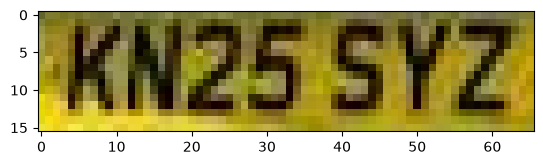

In [82]:
plt.imshow(cropped_plate)

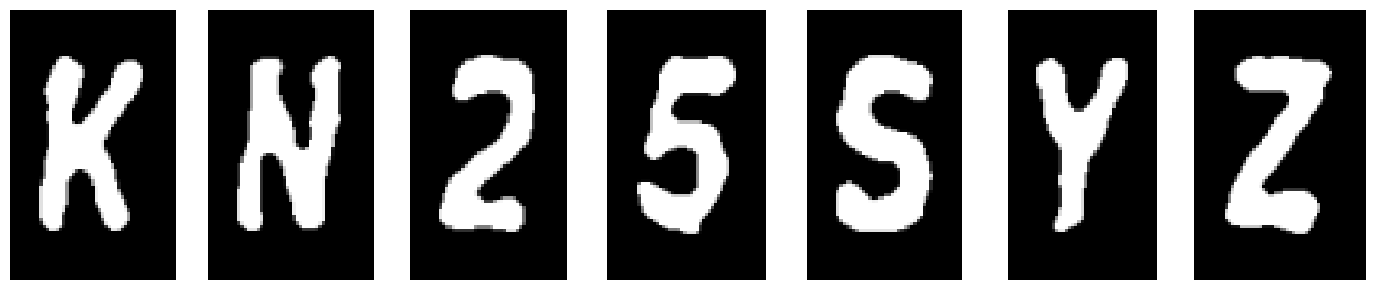

In [102]:
ishow(cropped_plate , title="Cropped Plate")
cropped_plate_normalized = normalize(cropped_plate)
ishow(cropped_plate_normalized , title="Normalized Plate")

cropped_plate_deleted_noise = delete_noize(cropped_plate_normalized)
ishow(cropped_plate_deleted_noise , title="Deleted Noise Plate")

cropped_plate_split_chars = segment_plate_characters(cropped_plate_deleted_noise, shrink=0.7)

for i in range(len(cropped_plate_split_chars)):
    ishow(cropped_plate_split_chars[i], title=f"Split Character {i}")
    

In [103]:
#تست
s = cropped_plate_split_chars[4]
ishow(s, title="Split Character 4")
s = cv2.resize(s, (28, 28))
s = s.astype('float32') / 255.0
s = s.reshape(1, 28, 28, 1)

label = model.predict(s).argmax()
print("label:", balanced_label_to_char(label))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
label: S


In [261]:

def detect_and_recognize_plate(image):
    ishow(image)
    results = yolo_model.predict(image, conf=0.5)
    cor = results[0].boxes.xyxy[0].tolist()
    x1, y1, x2, y2 = int(cor[0]), int(cor[1]), int(cor[2]), int(cor[3])
    cropped_plate = image[ y1+3:y2-3 , x1+3:x2-3 ]
    cv2.rectangle(image, (x1, y1), (x2, y2), (0 , 255, 0), 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    cropped_plate_normalized = normalize(cropped_plate)
    cropped_plate_deleted_noise = delete_noize(cropped_plate_normalized)
    cropped_plate_split_chars = segment_plate_characters(cropped_plate_deleted_noise, shrink=0.7)
    
    recognized_chars = []   
    for char_img in cropped_plate_split_chars:
        char_img_resize = cv2.resize(char_img, (28, 28))
        char_img_resize = char_img_resize.astype('float32') / 255.0
        char_img_reshape = char_img_resize.reshape(1, 28, 28, 1)
        label = model.predict(char_img_reshape).argmax()
        recognized_chars.append(balanced_label_to_char(label))
    
    cv2.putText(image , "".join(recognized_chars) , ((x1), y1-10) , cv2.FONT_HERSHEY_SIMPLEX , .8 , (255 ,255 , 255)  , 6 , cv2.LINE_AA)
    cv2.putText(image , "".join(recognized_chars) , ((x1), y1-10) , cv2.FONT_HERSHEY_SIMPLEX , .8 , (0 , 0 , 255)  , 2 , cv2.LINE_AA)
    ishow(image , title="Detected Plate with Recognized Characters")
    ishow(cropped_plate_normalized)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    return ''.join(recognized_chars)
    
    
    



0: 640x480 1 licence_plate, 4562.3ms
Speed: 848.3ms preprocess, 4562.3ms inference, 86.9ms postprocess per image at shape (1, 3, 640, 480)


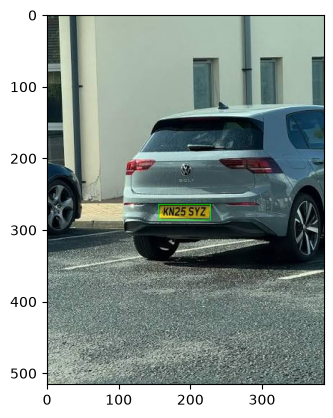

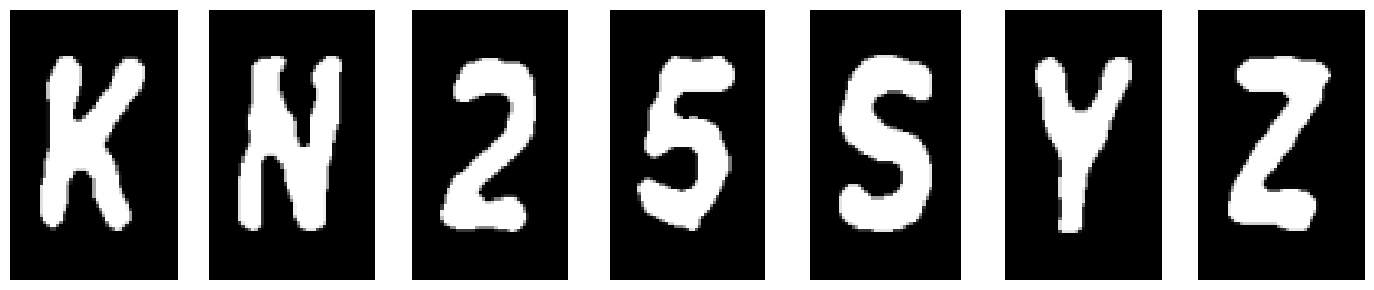

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 968ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


'KN25SYZ'

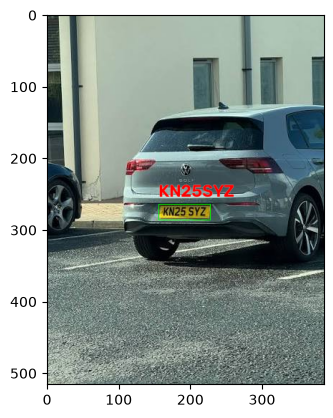

In [269]:
img_tets = cv2.imread("plate.png")
recognized_plate = detect_and_recognize_plate(img_tets)
recognized_plate